# Detect injections for cached discharges

Load cached `Discharge` objects from `data/discharges`, detect injections on
**channel 2** (energy window 6660 eV ±60 eV), store them in `discharge.injections`,
refresh `created_at` timestamps, and save each discharge back to its `.pkl`.

In [1]:
# Cell 1 — load all cached Discharge objects from data/discharges
from pathlib import Path

import pandas as pd

# Notebook lives in global_stats/, so step up one level to reach the repo root.
repo_root = Path.cwd().parent if Path.cwd().name == "global_stats" else Path.cwd()
discharges_dir = repo_root / "data" / "discharges"
cache_filename = "discharge_object.pkl"

# Map folder name -> loaded Discharge object (skip folders without a cache).
discharges = {}
for folder_path in sorted(p for p in discharges_dir.iterdir() if p.is_dir()):
    cache_file = folder_path / "cache" / cache_filename
    if not cache_file.exists():
        print(f"[SKIP] {folder_path.name}: no cache at {cache_file}")
        continue
    discharges[folder_path.name] = pd.read_pickle(cache_file)
    print(f"[LOADED] {folder_path.name}")

print(f"\nLoaded {len(discharges)} discharge(s).")

[LOADED] 2025-04-29--10-19
[LOADED] 2025-04-29--10-24
[LOADED] 2025-04-29--10-42
[LOADED] 2025-04-29--10-49
[LOADED] 2025-04-29--11-17
[LOADED] 2025-04-29--11-19
[LOADED] 2025-04-29--11-23
[LOADED] 2025-04-29--11-32
[LOADED] 2025-04-29--11-37
[LOADED] 2025-04-29--12-14
[LOADED] 2025-04-29--12-28
[LOADED] 2025-04-29--12-50
[LOADED] 2025-04-29--12-58
[LOADED] 2025-04-29--13-17
[LOADED] 2025-04-29--13-51
[LOADED] test

Loaded 16 discharge(s).


In [39]:
# Cell 1b — RE-LOAD every discharge FRESH from raw txt folders in data/discharges.
# Purpose: test the newly-applied io.py trim (min_frame_counts threshold) on raw
# data instead of the old cached .pkl objects. Kept in a SEPARATE dict so the
# cache loaded in Cell 1 is untouched. To analyze these instead, just swap
# `discharges` -> `new_discharges` in Cell 2 / Cell 3.
import importlib
import pha_lib.io
importlib.reload(pha_lib.io)  # pick up the new min_frame_counts trim edit
from pha_lib import io

# Reuse repo_root / discharges_dir from Cell 1 (data/discharges).
# Each subfolder holds the raw test_<frame>.txt files for one discharge.
new_discharges = {}
for folder_path in sorted(p for p in discharges_dir.iterdir() if p.is_dir()):
    try:
        # load_test_folder applies the trim (min_frame_counts default = 2).
        new_discharges[folder_path.name] = io.load_test_folder(
            folder_path, discharge_id=folder_path.name
        )
        print(f"[LOADED] {folder_path.name}")
    except Exception as exc:
        # A folder may lack raw txt files (e.g. only a cache) — report and skip.
        print(f"[SKIP] {folder_path.name}: {exc}")

print(f"\nFreshly loaded {len(new_discharges)} discharge(s) into new_discharges.")


[LOADED] 2025-04-29--10-19
[LOADED] 2025-04-29--10-24
[LOADED] 2025-04-29--10-42
[LOADED] 2025-04-29--10-49
[LOADED] 2025-04-29--11-17
[LOADED] 2025-04-29--11-19
[LOADED] 2025-04-29--11-23
[LOADED] 2025-04-29--11-32
[LOADED] 2025-04-29--11-37
[LOADED] 2025-04-29--12-14
[LOADED] 2025-04-29--12-28
[LOADED] 2025-04-29--12-50
[LOADED] 2025-04-29--12-58
[LOADED] 2025-04-29--13-17
[LOADED] 2025-04-29--13-51
[LOADED] test

Freshly loaded 16 discharge(s) into new_discharges.


In [35]:
# Quick check: confirm the new trim cut the stray-count tails. Compare the last
# frame number kept in the cached vs freshly-loaded version for a few discharges.
for name in ["2025-04-29--11-19", "2025-04-29--12-58", "2025-04-29--11-23"]:
    old_last = int(discharges[name].channels[2].frame_numbers[-1])
    new_last = int(new_discharges[name].channels[2].frame_numbers[-1])
    print(f"{name}: cached last frame = {old_last}, fresh last frame = {new_last}")


2025-04-29--11-19: cached last frame = 399, fresh last frame = 196
2025-04-29--12-58: cached last frame = 218, fresh last frame = 141
2025-04-29--11-23: cached last frame = 305, fresh last frame = 305


In [40]:
# Cell 2 — detect injections on channel 2 and store them in discharge.injections
from datetime import datetime

from pha_lib.timetrace import integrate_energy_window


import importlib
import pha_lib.discharges
importlib.reload(pha_lib.discharges)

from pha_lib.discharges import detect_injections, InjectionDetectionConfig

# Detection settings: Fe XXV line at 6660 eV, ±60 eV window (pipeline defaults).
LINE_ENERGY_eV = 6660.0
HALF_WIDTH_eV = 60.0
DETECT_CHANNEL = 2
detection_config = InjectionDetectionConfig()  # default parameters

detect_rows = []
for folder_name, discharge in new_discharges.items():
    # Some discharges may not have channel 2 — record and skip those.
    if DETECT_CHANNEL not in discharge.channels:
        print(f"[SKIP] {folder_name}: no channel {DETECT_CHANNEL}")
        detect_rows.append({"folder": folder_name, "n_injections": None,
                            "error": f"no channel {DETECT_CHANNEL}"})
        continue

    # Build the per-channel time trace, then run injection detection on it.
    channel = discharge.channels[DETECT_CHANNEL]
    trace = integrate_energy_window(channel, LINE_ENERGY_eV, HALF_WIDTH_eV)
    injections = detect_injections(trace, LINE_ENERGY_eV, detection_config)

    # Stamp a fresh detection time on every injection for cache provenance.
    now = datetime.now()
    for inj in injections:
        inj.created_at = now

    # Attach injections to the discharge and refresh its own timestamp too.
    discharge.injections = injections
    discharge.created_at = now

    print(f"[OK] {folder_name}: {len(injections)} injection(s)")
    detect_rows.append({"folder": folder_name, "n_injections": len(injections),
                        "error": ""})

print("\nDetection summary:")
print(pd.DataFrame(detect_rows).to_string(index=False))

[OK] 2025-04-29--10-19: 4 injection(s)
[OK] 2025-04-29--10-24: 4 injection(s)
[OK] 2025-04-29--10-42: 1 injection(s)
[OK] 2025-04-29--10-49: 1 injection(s)
[OK] 2025-04-29--11-17: 3 injection(s)
[OK] 2025-04-29--11-19: 3 injection(s)
[OK] 2025-04-29--11-23: 3 injection(s)
[OK] 2025-04-29--11-32: 3 injection(s)
[OK] 2025-04-29--11-37: 1 injection(s)
[OK] 2025-04-29--12-14: 3 injection(s)
[OK] 2025-04-29--12-28: 5 injection(s)
[OK] 2025-04-29--12-50: 2 injection(s)
[OK] 2025-04-29--12-58: 2 injection(s)
[OK] 2025-04-29--13-17: 2 injection(s)
[OK] 2025-04-29--13-51: 5 injection(s)
[OK] test: 5 injection(s)

Detection summary:
           folder  n_injections error
2025-04-29--10-19             4      
2025-04-29--10-24             4      
2025-04-29--10-42             1      
2025-04-29--10-49             1      
2025-04-29--11-17             3      
2025-04-29--11-19             3      
2025-04-29--11-23             3      
2025-04-29--11-32             3      
2025-04-29--11-37          

In [3]:
# Cell 3 — save updated discharges back to their .pkl cache files
save_rows = []
for folder_name, discharge in discharges.items():
    cache_file = discharges_dir / folder_name / "cache" / cache_filename
    try:
        # Overwrite the same cache file with the updated discharge (now carrying
        # detected injections and refreshed timestamps).
        pd.to_pickle(discharge, cache_file)
        n_inj = len(discharge.injections) if discharge.injections is not None else 0
        print(f"[SAVED] {folder_name}: {n_inj} injection(s) -> {cache_file}")
        save_rows.append({"folder": folder_name, "status": "saved",
                          "n_injections": n_inj, "error": ""})
    except Exception as exc:
        print(f"[FAILED] {folder_name}: {exc}")
        save_rows.append({"folder": folder_name, "status": "failed",
                          "n_injections": None, "error": str(exc)})

print("\nSave summary:")
print(pd.DataFrame(save_rows).to_string(index=False))

[SAVED] 2025-04-29--10-19: 4 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-19\cache\discharge_object.pkl
[SAVED] 2025-04-29--10-24: 4 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-24\cache\discharge_object.pkl
[SAVED] 2025-04-29--10-42: 1 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-42\cache\discharge_object.pkl
[SAVED] 2025-04-29--10-49: 1 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-49\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-17: 3 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-17\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-19: 5 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-19\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-23: 3 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-23\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-32: 3 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharg

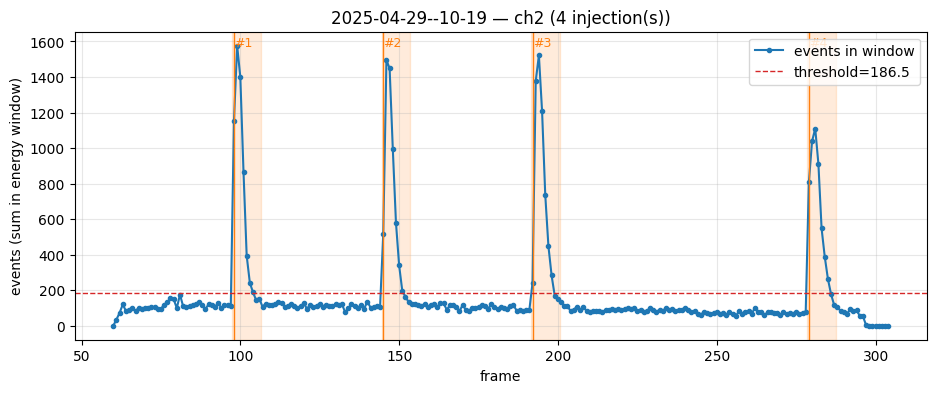

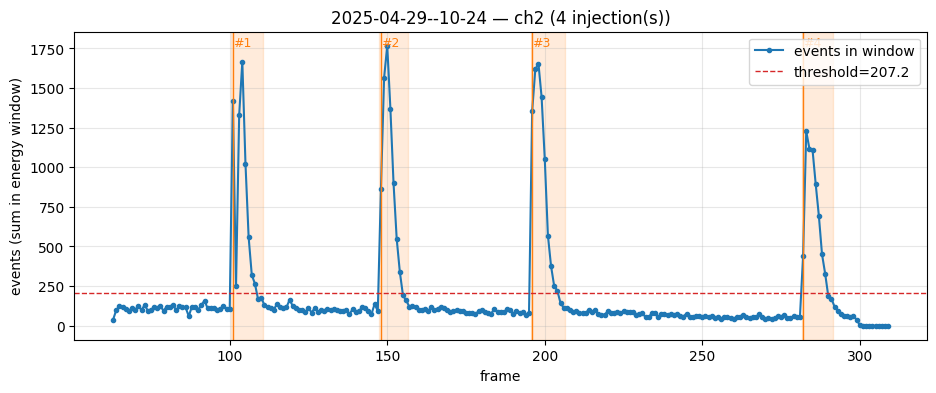

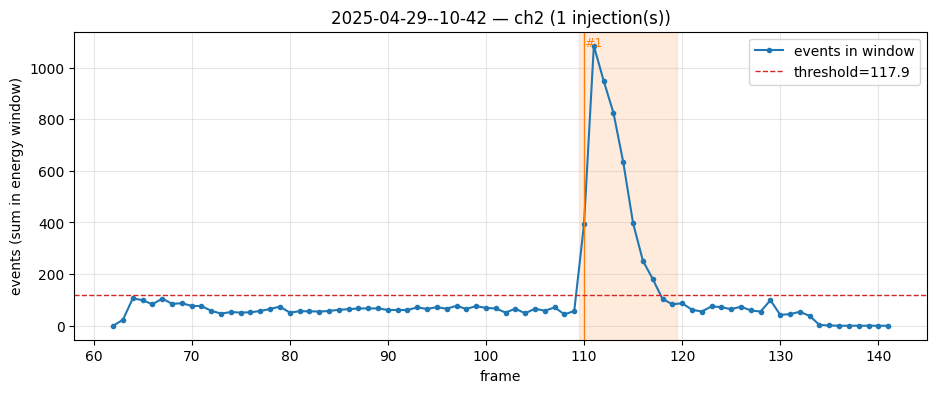

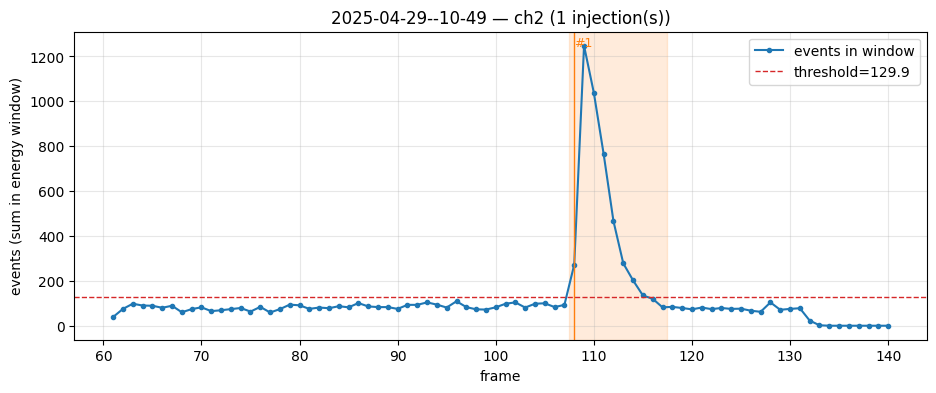

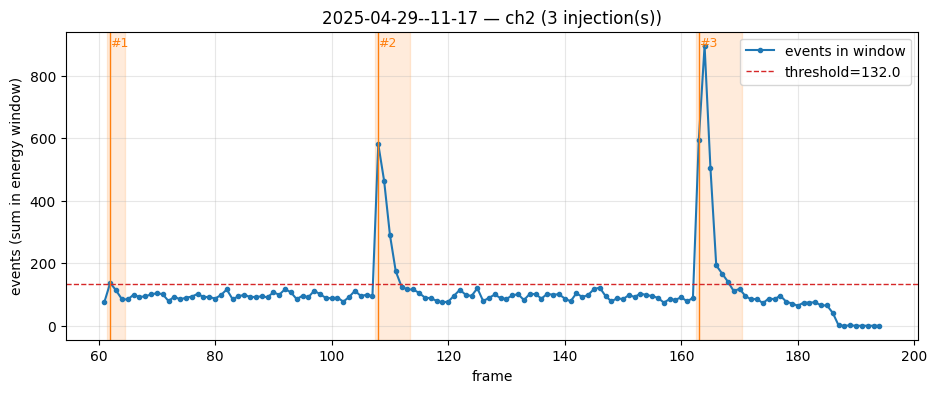

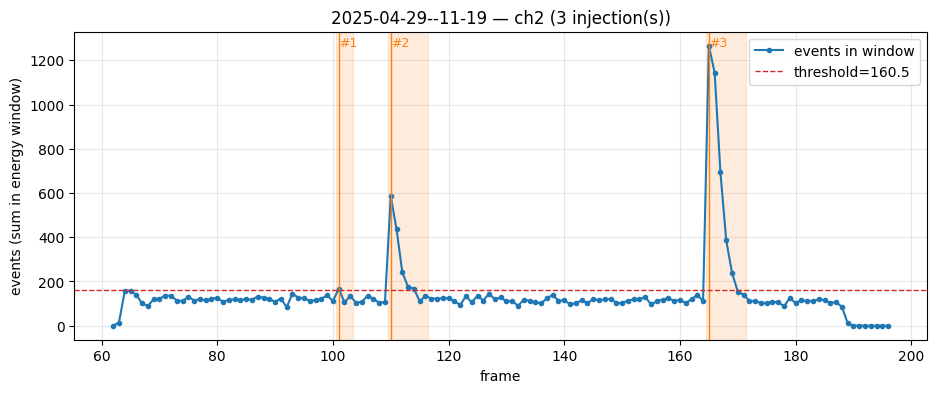

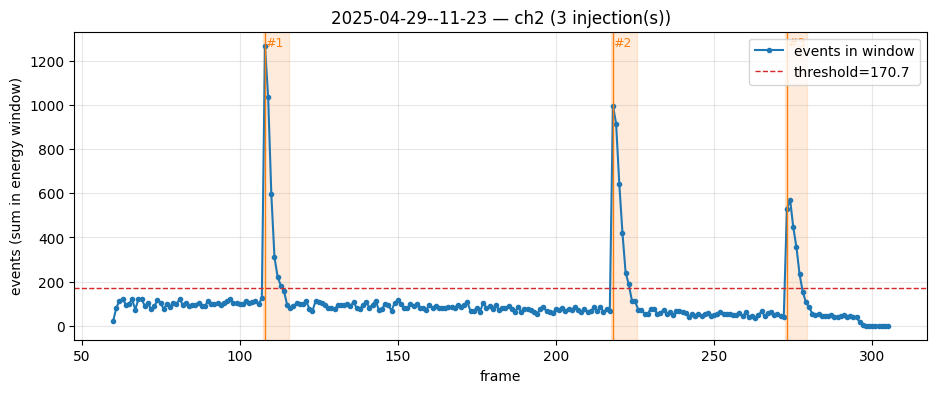

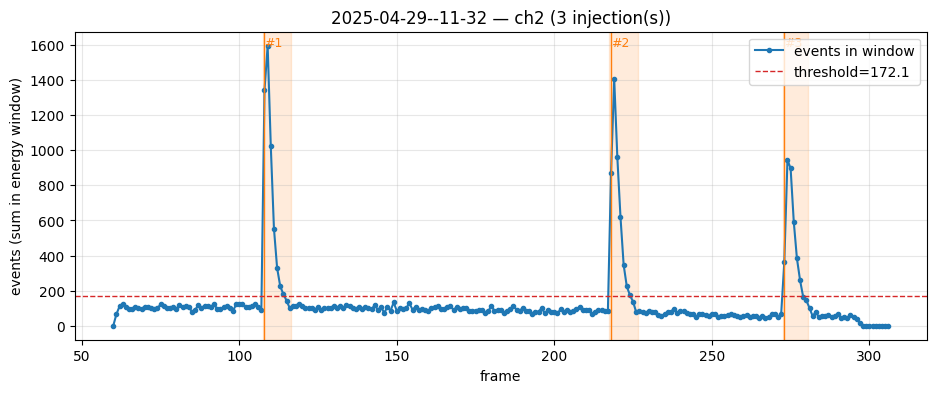

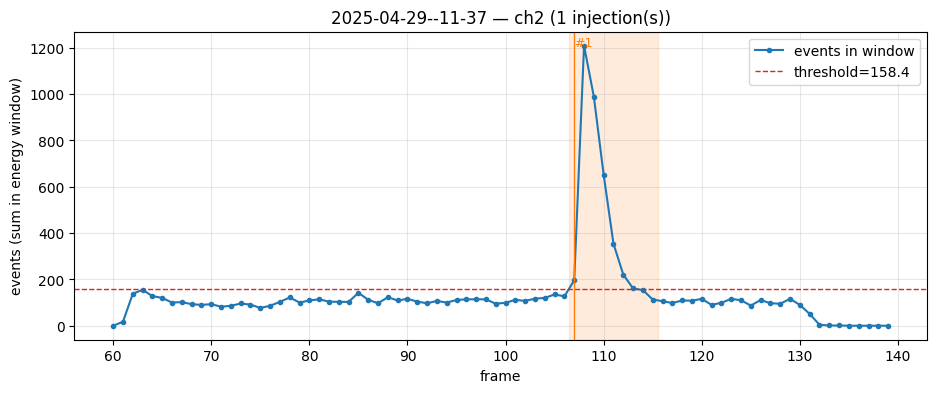

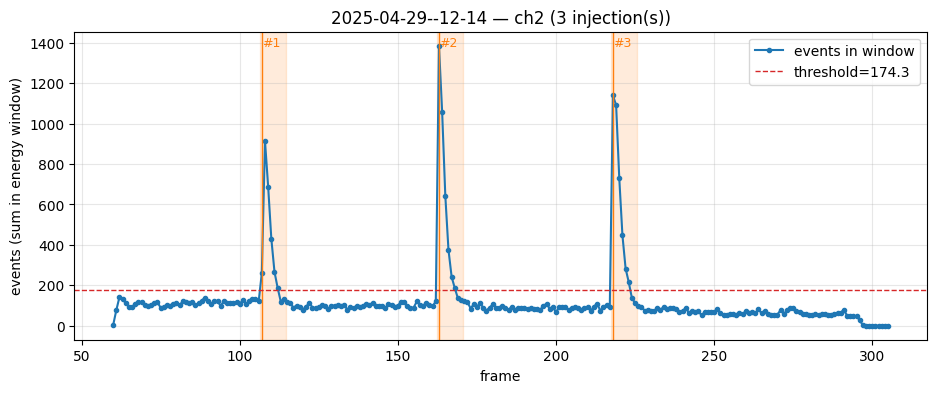

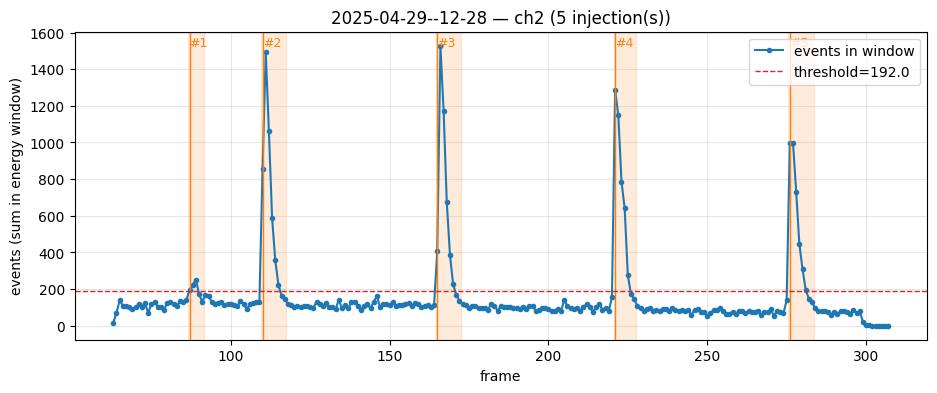

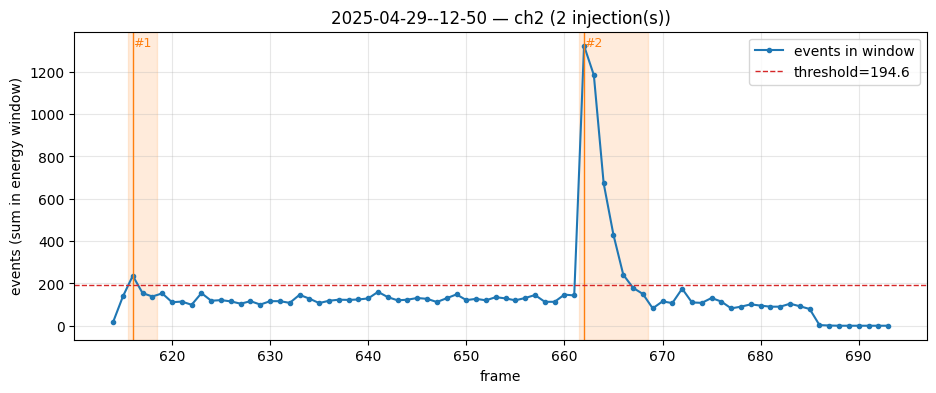

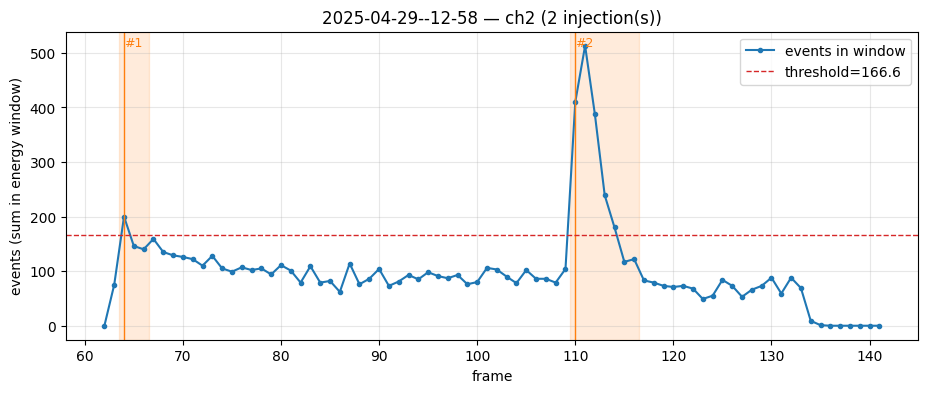

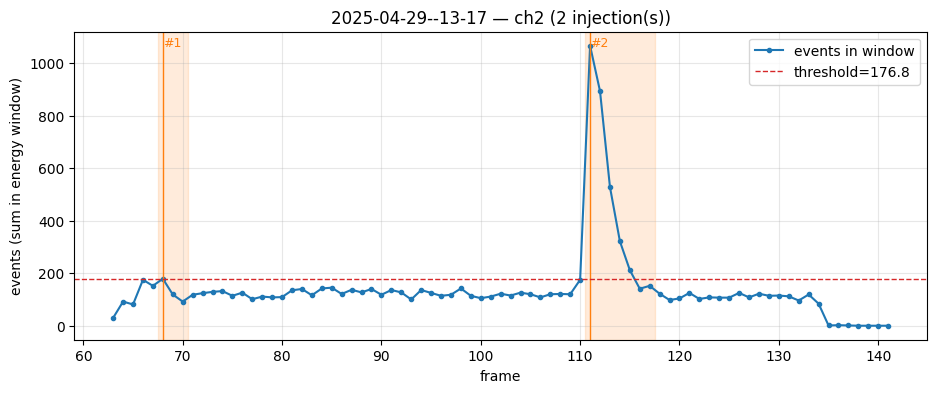

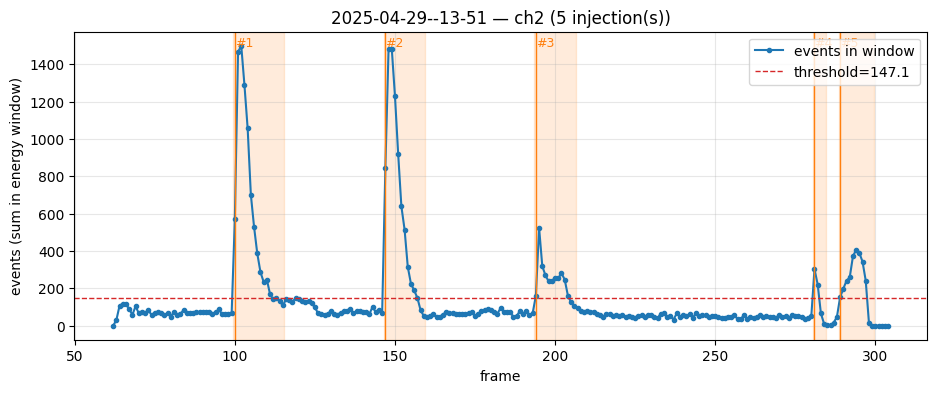

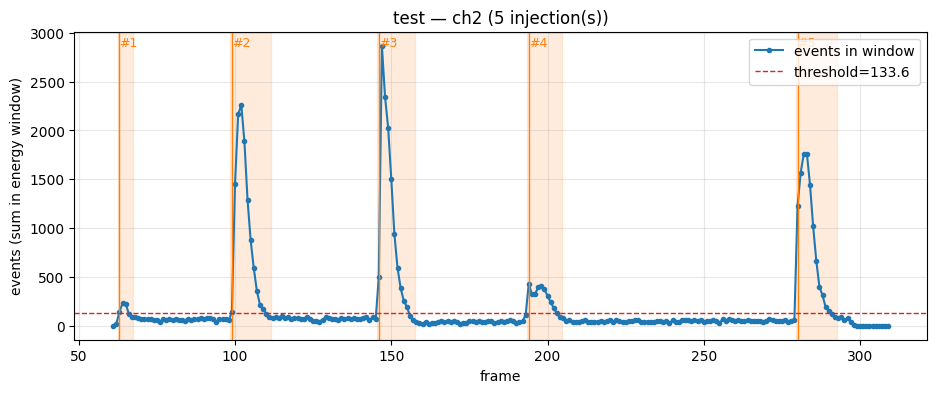

In [41]:
# Cell 4 — plot each discharge's channel-2 timetrace with marked injections
import matplotlib.pyplot as plt

from pha_lib.plotting import plot_timetrace_with_injections
from pha_lib.discharges import _robust_background_and_scale

for folder_name, discharge in new_discharges.items():
    # Only channel 2 was analyzed, so skip discharges without it.
    if DETECT_CHANNEL not in discharge.channels:
        continue

    # Rebuild the same trace used for detection (no cache needed, in-memory).
    channel = discharge.channels[DETECT_CHANNEL]
    trace = integrate_energy_window(channel, LINE_ENERGY_eV, HALF_WIDTH_eV)

    # Recompute the detection threshold exactly as detect_injections does:
    # robust background + threshold_factor * robust noise scale.
    bg, scale = _robust_background_and_scale(trace.values)
    thr = bg + detection_config.threshold_factor * scale

    # Injections detected in Cell 2 (empty list if none / not yet run).
    injections = discharge.injections or []

    # One figure per discharge; reuse the library plotting helper.
    fig, ax = plt.subplots(figsize=(11, 4))
    plot_timetrace_with_injections(
        trace,
        injections,
        ax=ax,
        title=f"{folder_name} — ch{DETECT_CHANNEL} "
              f"({len(injections)} injection(s))",
    )

    # Draw the detection threshold as a dashed red line.
    ax.axhline(thr, color="tab:red", ls="--", lw=1, label=f"threshold={thr:.1f}")
    ax.legend(loc="upper right")

    plt.show()

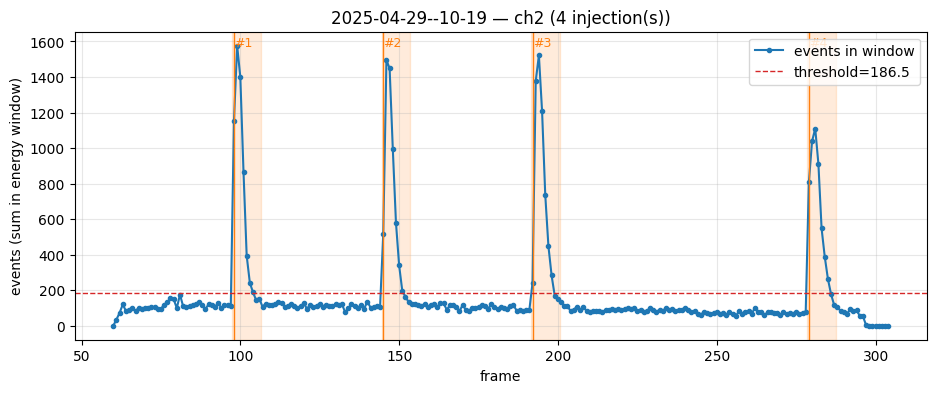

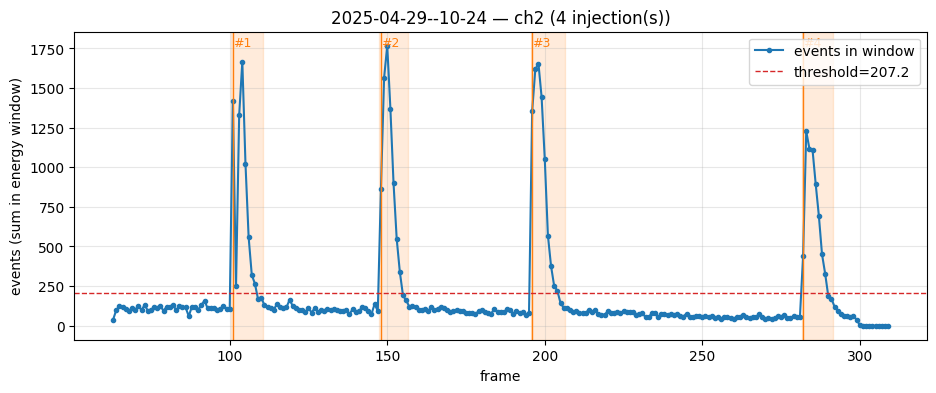

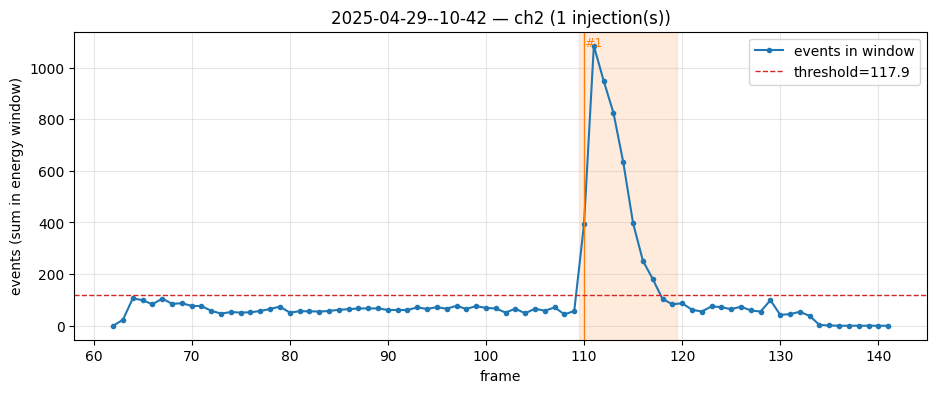

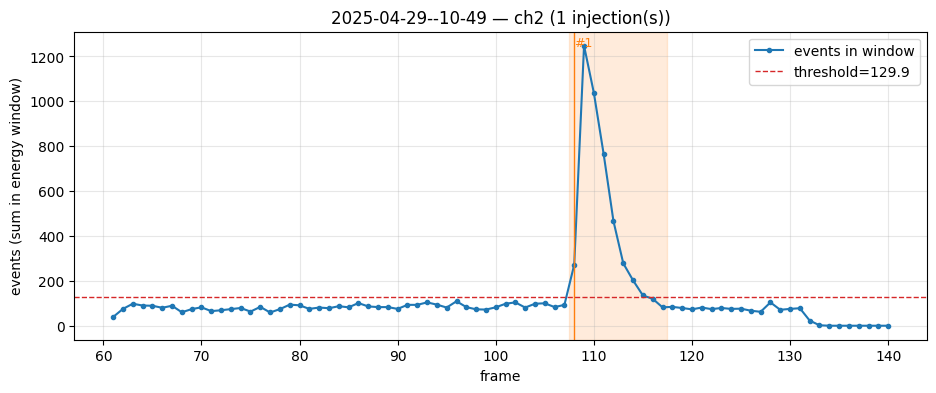

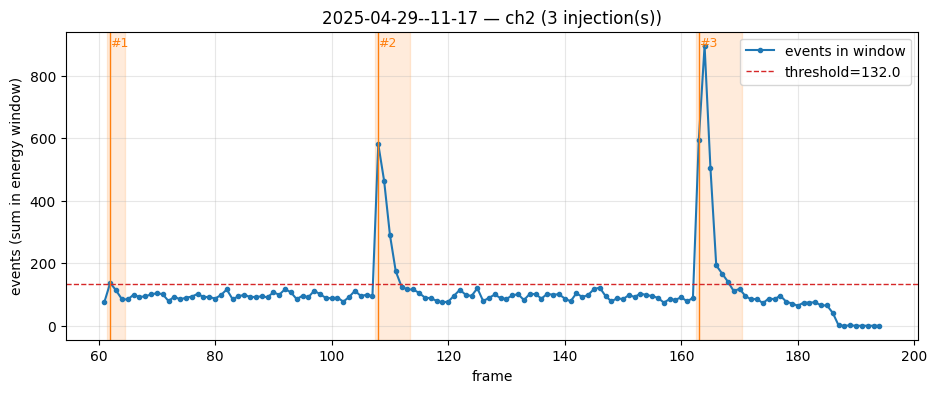

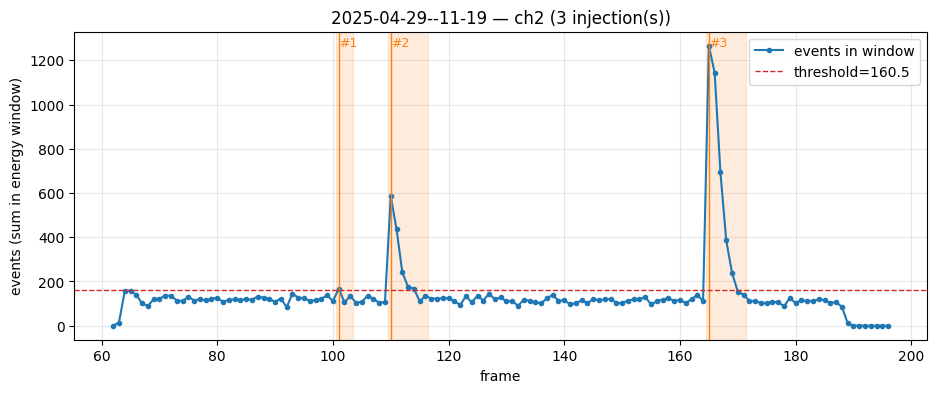

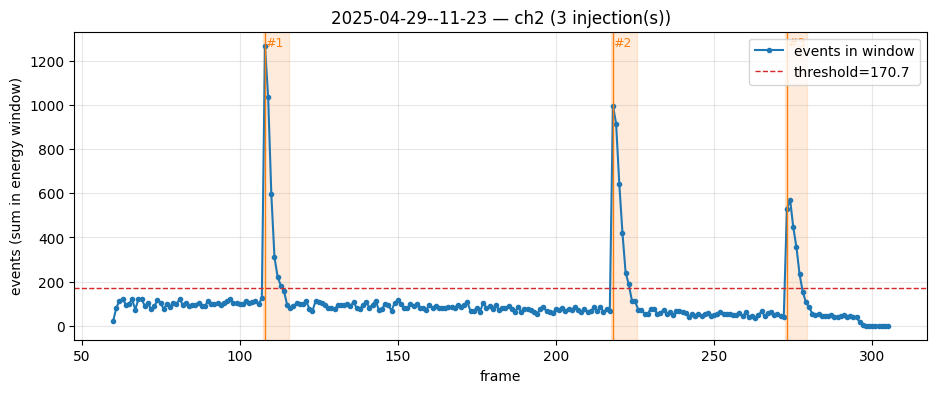

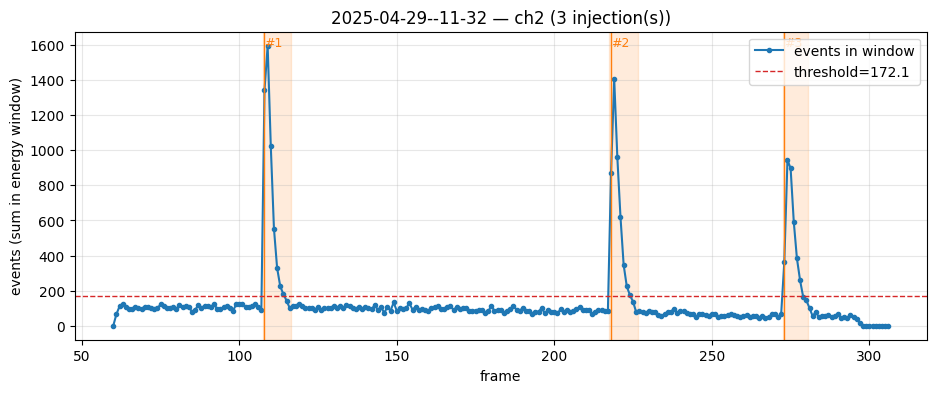

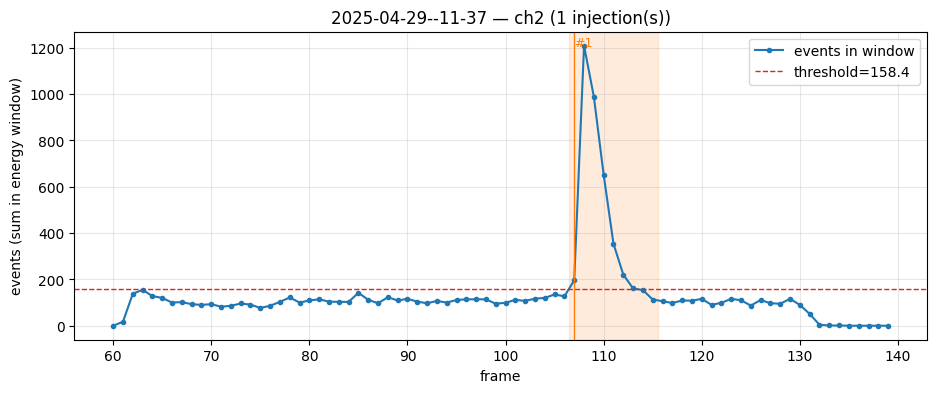

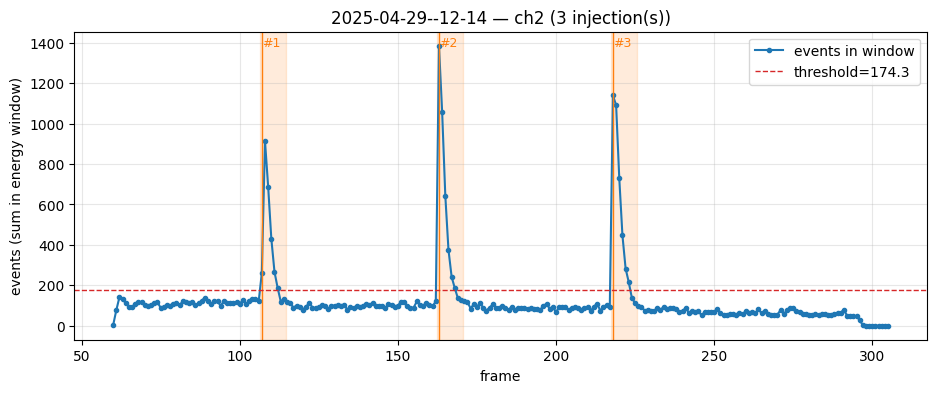

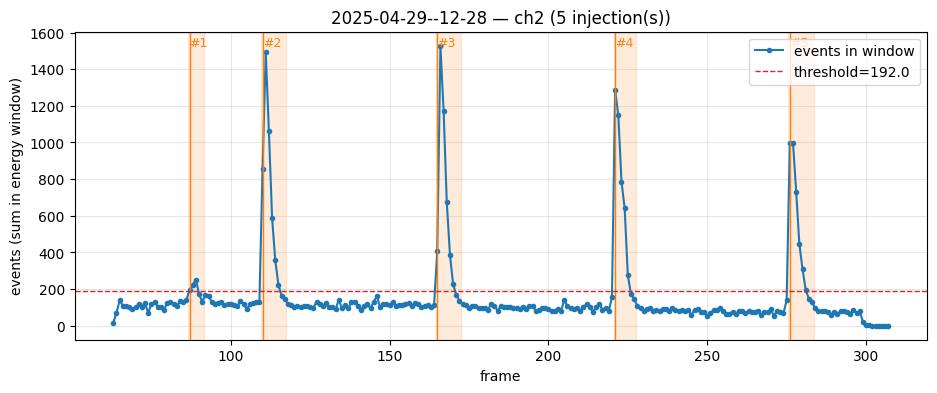

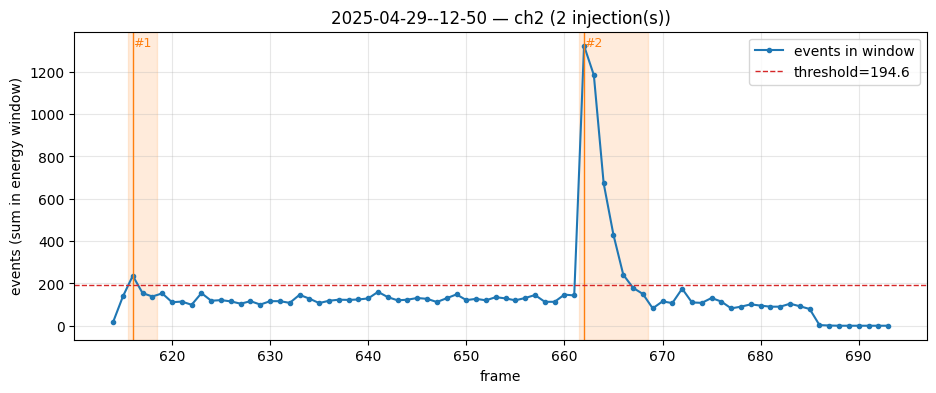

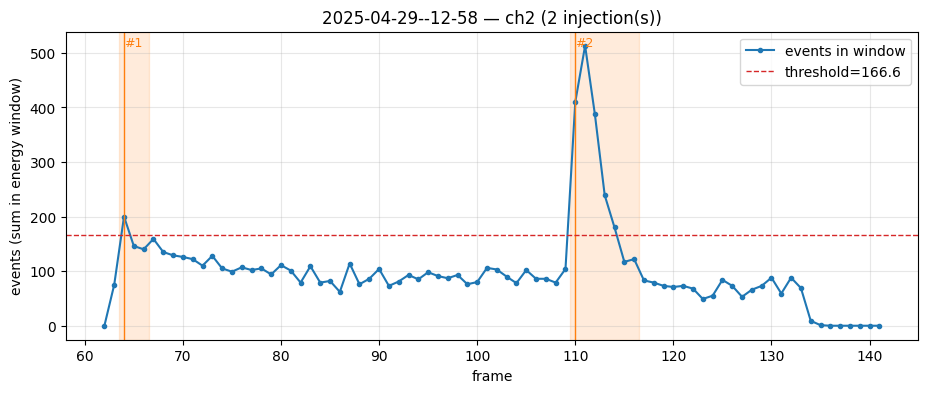

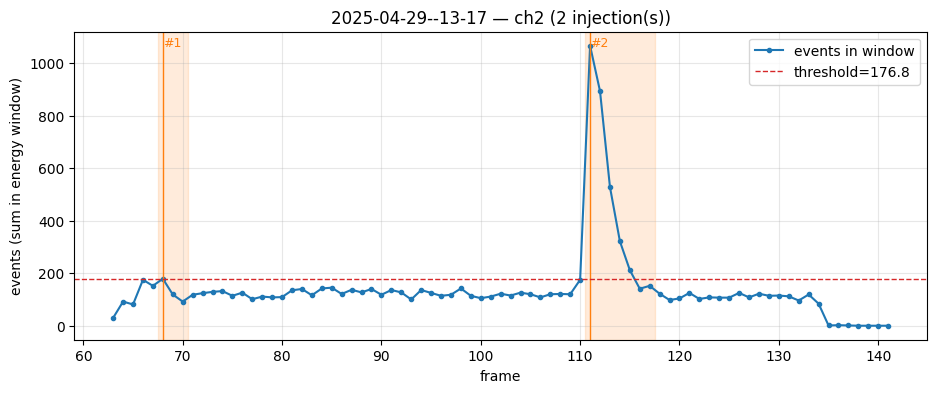

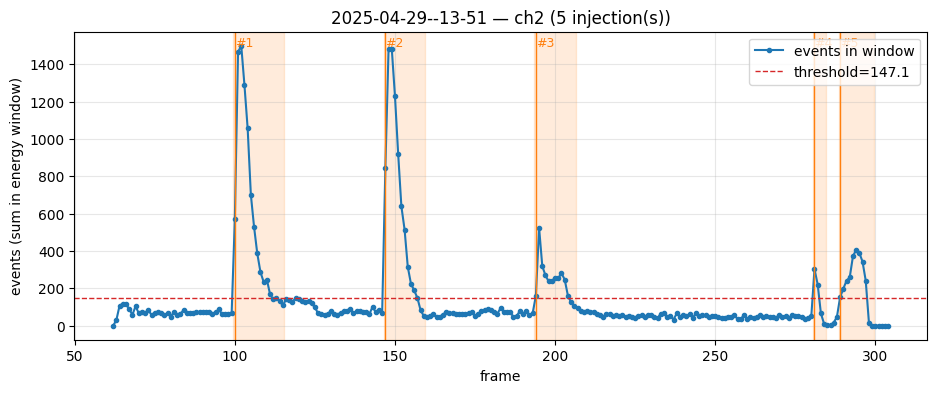

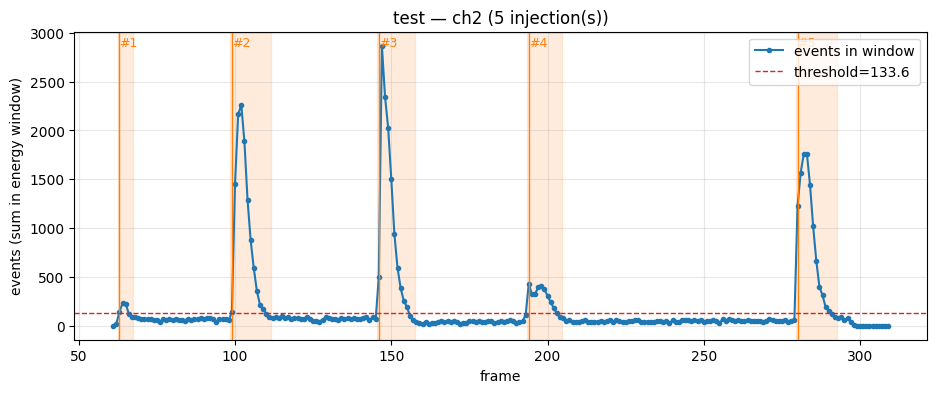

In [42]:
# Cell 4 — plot each discharge's channel-2 timetrace with marked injections
import matplotlib.pyplot as plt

from pha_lib.plotting import plot_timetrace_with_injections
from pha_lib.discharges import _robust_background_and_scale

for folder_name, discharge in new_discharges.items():
    # Only channel 2 was analyzed, so skip discharges without it.
    if DETECT_CHANNEL not in discharge.channels:
        continue

    # Rebuild the same trace used for detection (no cache needed, in-memory).
    channel = discharge.channels[DETECT_CHANNEL]
    trace = integrate_energy_window(channel, LINE_ENERGY_eV, HALF_WIDTH_eV)

    # Recompute the detection threshold exactly as detect_injections does:
    # robust background + threshold_factor * robust noise scale.
    bg, scale = _robust_background_and_scale(trace.values)
    thr = bg + detection_config.threshold_factor * scale

    # Injections detected in Cell 2 (empty list if none / not yet run).
    injections = discharge.injections or []

    # One figure per discharge; reuse the library plotting helper.
    fig, ax = plt.subplots(figsize=(11, 4))
    plot_timetrace_with_injections(
        trace,
        injections,
        ax=ax,
        title=f"{folder_name} — ch{DETECT_CHANNEL} "
              f"({len(injections)} injection(s))",
    )

    # Draw the detection threshold as a dashed red line.
    ax.axhline(thr, color="tab:red", ls="--", lw=1, label=f"threshold={thr:.1f}")
    ax.legend(loc="upper right")

    plt.show()

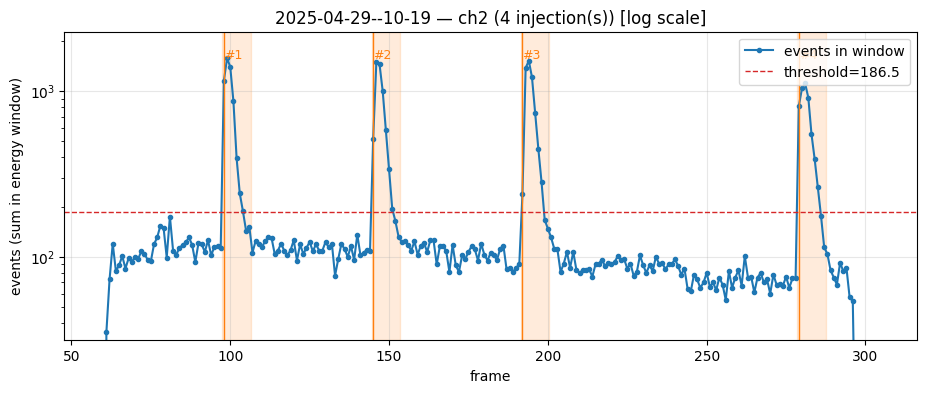

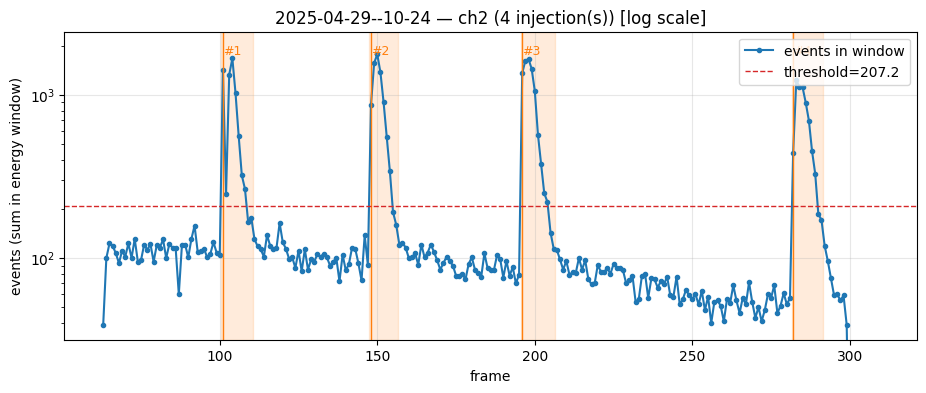

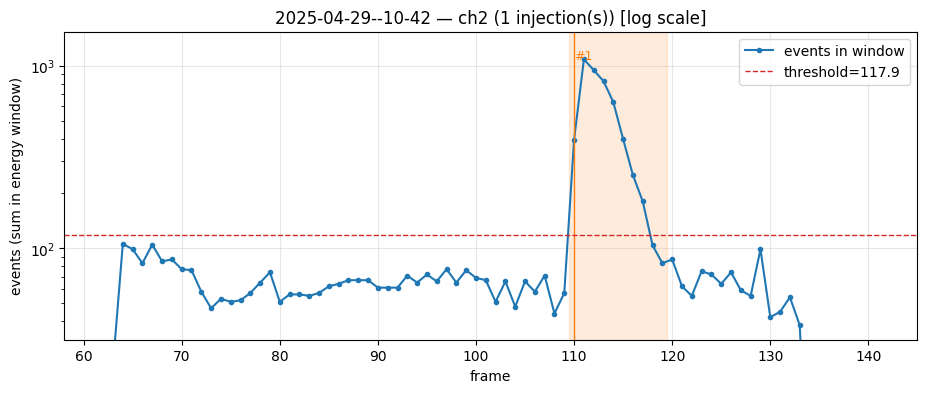

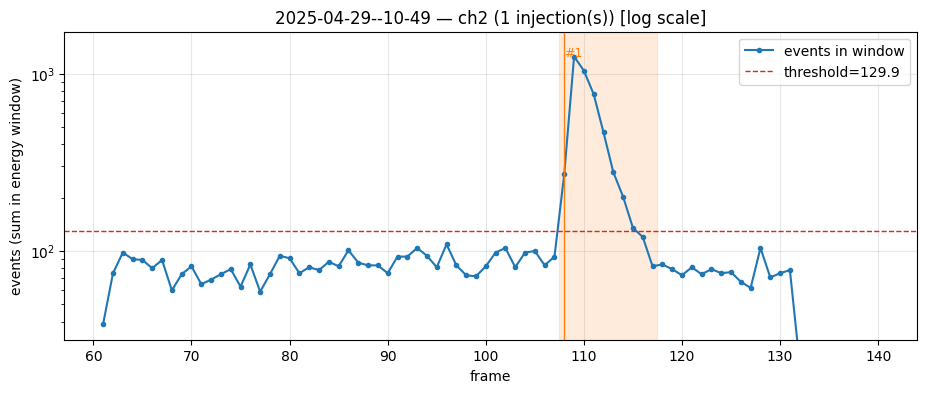

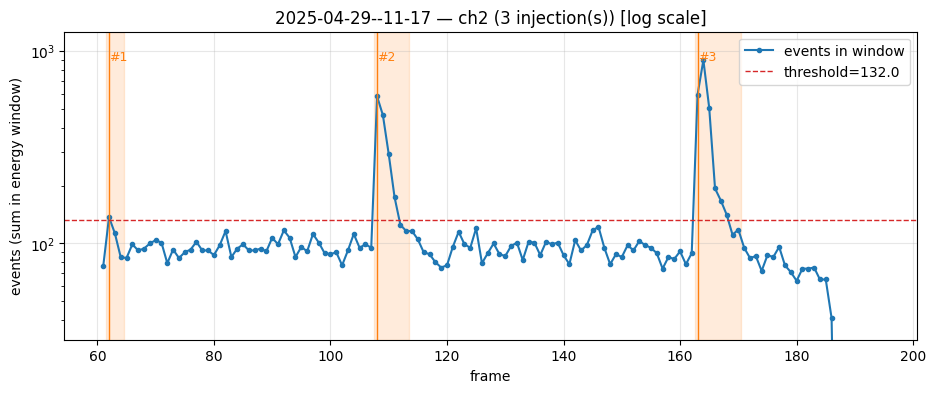

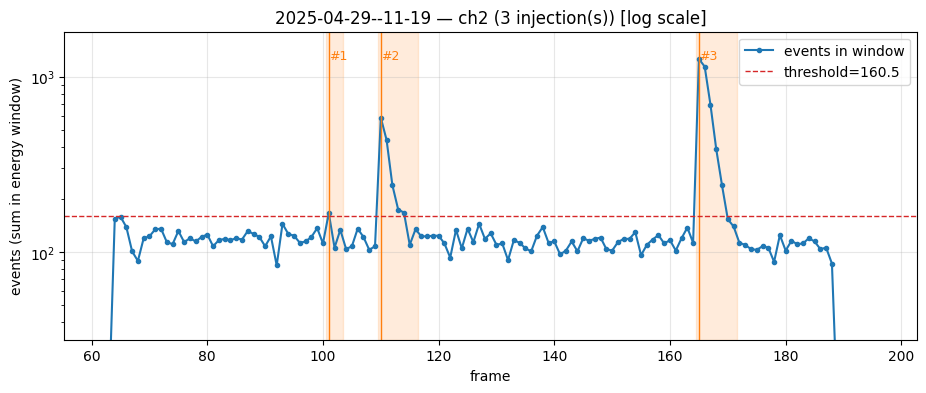

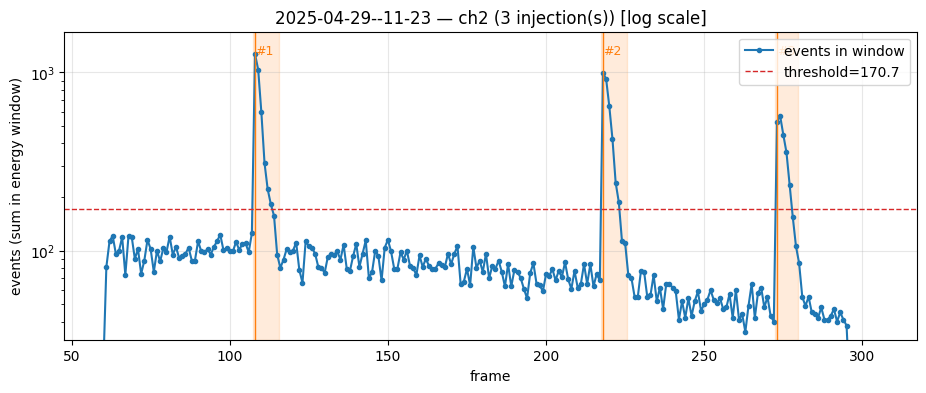

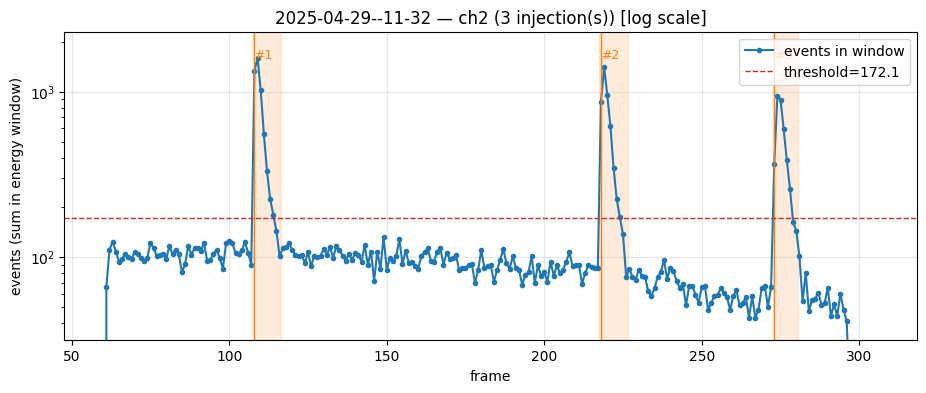

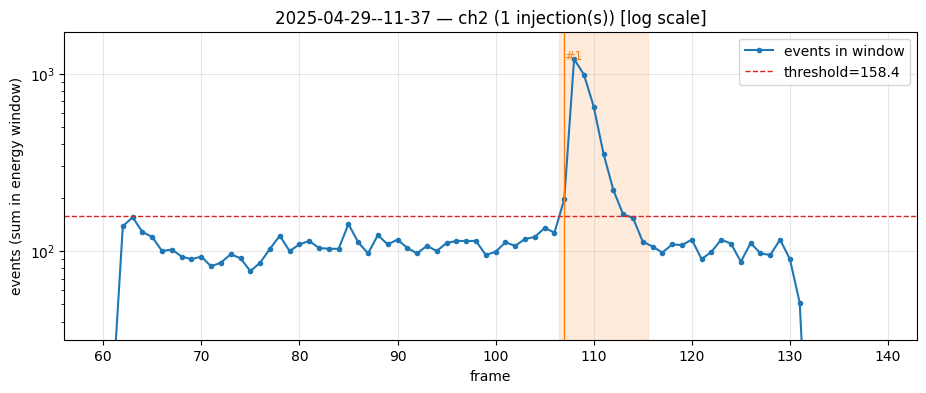

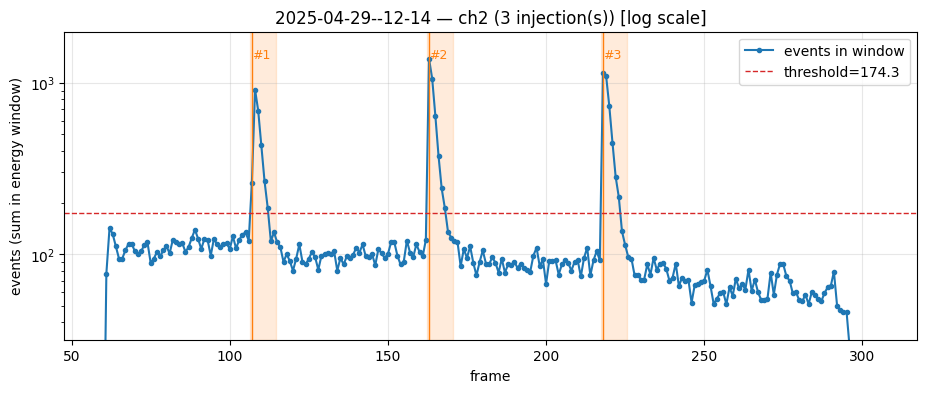

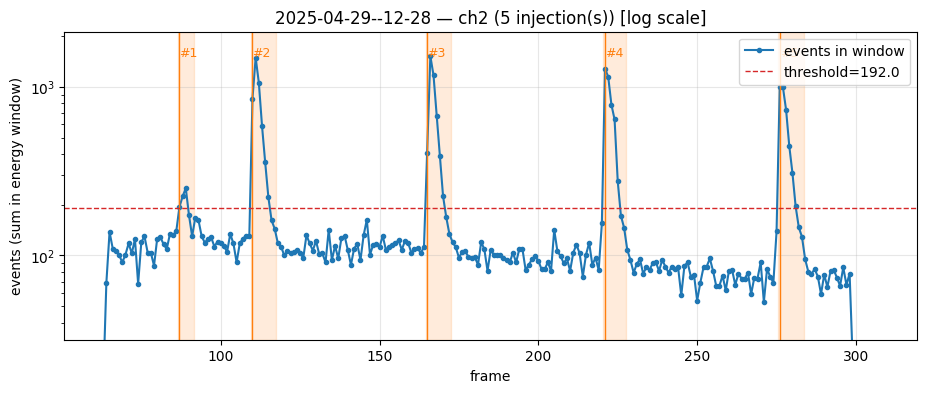

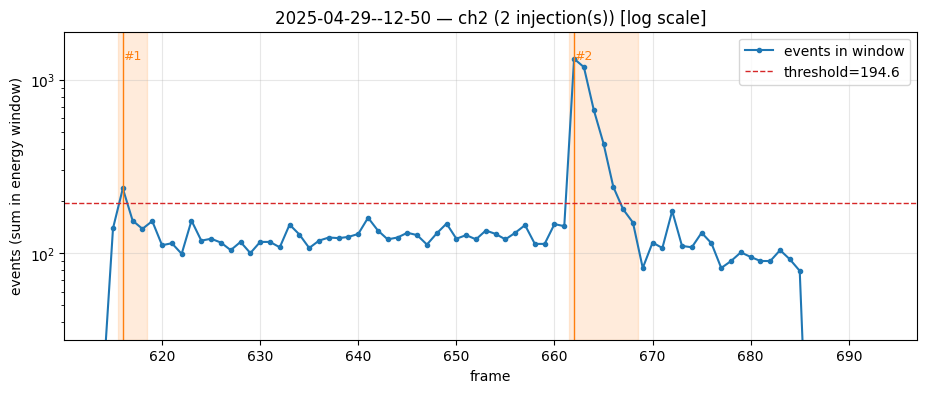

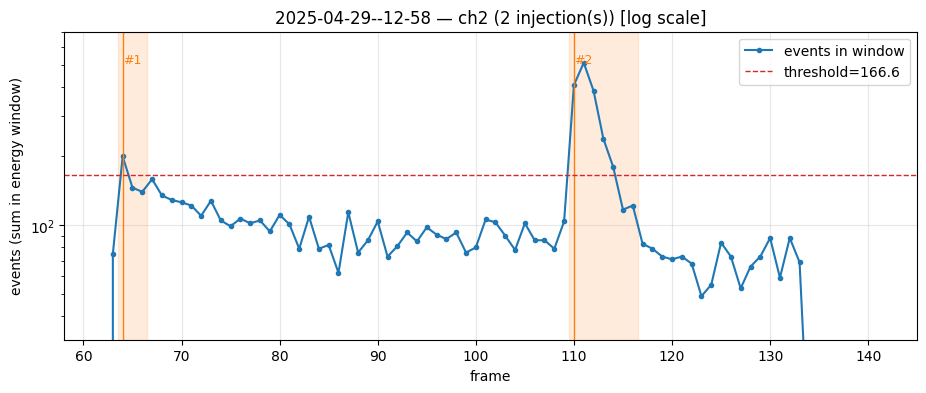

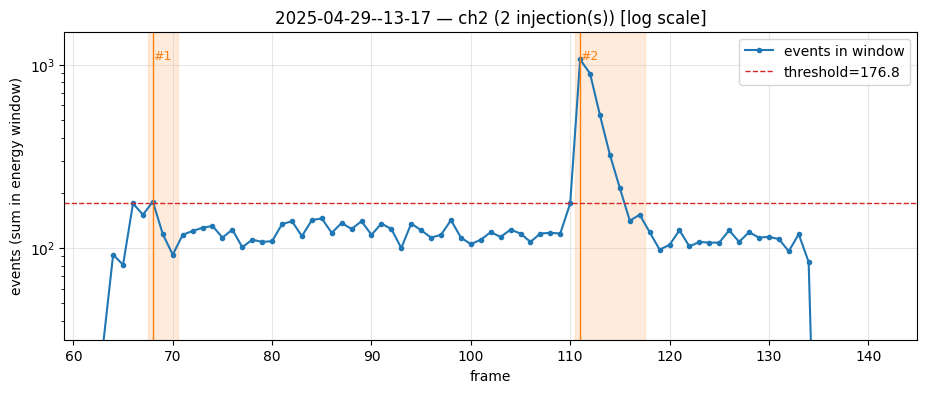

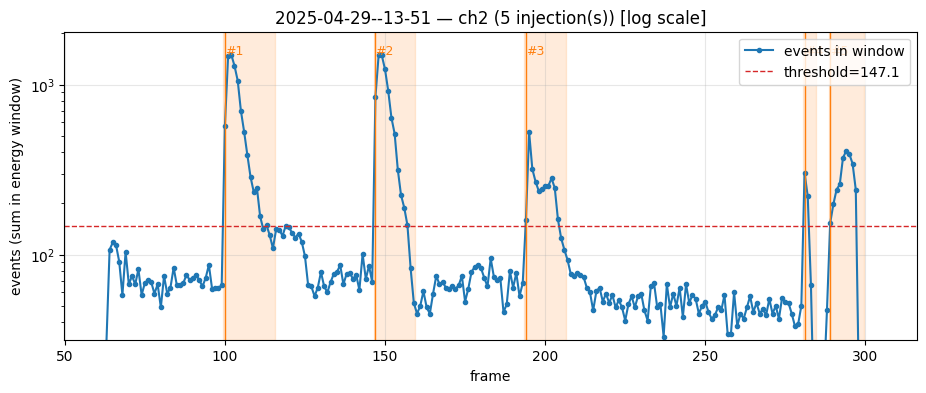

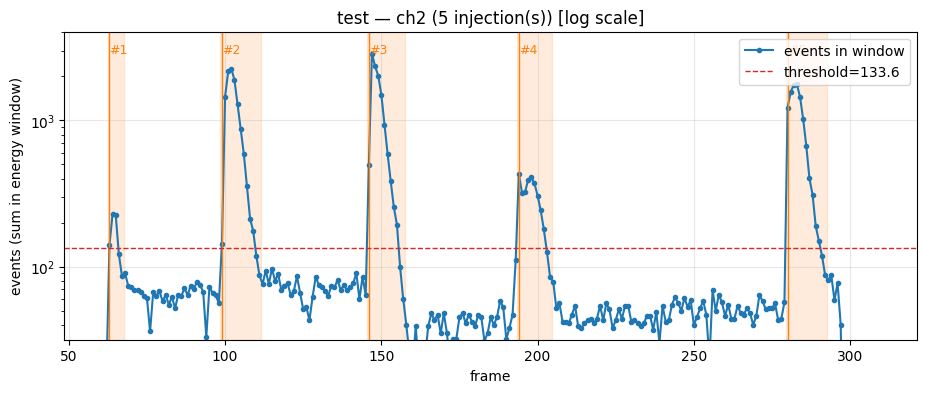

In [45]:
# Cell 4 (log scale) — same as Cell 4 but with logarithmic y-axis
import matplotlib.pyplot as plt

from pha_lib.plotting import plot_timetrace_with_injections
from pha_lib.discharges import _robust_background_and_scale

for folder_name, discharge in new_discharges.items():
    # Only channel 2 was analyzed, so skip discharges without it.
    if DETECT_CHANNEL not in discharge.channels:
        continue

    # Rebuild the same trace used for detection (no cache needed, in-memory).
    channel = discharge.channels[DETECT_CHANNEL]
    trace = integrate_energy_window(channel, LINE_ENERGY_eV, HALF_WIDTH_eV)

    # Recompute the detection threshold exactly as detect_injections does.
    bg, scale = _robust_background_and_scale(trace.values)
    thr = bg + detection_config.threshold_factor * scale

    # Injections detected in Cell 2 (empty list if none / not yet run).
    injections = discharge.injections or []

    # One figure per discharge; reuse the library plotting helper.
    fig, ax = plt.subplots(figsize=(11, 4))
    plot_timetrace_with_injections(
        trace,
        injections,
        ax=ax,
        title=f"{folder_name} — ch{DETECT_CHANNEL} "
              f"({len(injections)} injection(s)) [log scale]",
    )

    # Draw the detection threshold as a dashed red line.
    ax.axhline(thr, color="tab:red", ls="--", lw=1, label=f"threshold={thr:.1f}")
    ax.set_yscale("log")  # logarithmic y-axis
    ax.set_ylim(bottom=10**1.5)   # cut y-axis below 10^0.5 ≈ 3.16
    ax.legend(loc="upper right")

    plt.show()

In [15]:
# Cell 5 — print the length (in frames) of every detected injection
length_rows = []
for folder_name, discharge in discharges.items():
    for inj in (discharge.injections or []):
        # Length in frames, inclusive of both start and finish frames.
        length = inj.finish_frame - inj.start_frame + 1
        # Flag injections rejected by detection (is_true_injection == False).
        fake_tag = "" if inj.is_true_injection else "  <-- FAKE (not true injection)"
        print(f"{folder_name} #{inj.injection_no}: "
              f"frames {inj.start_frame}–{inj.finish_frame} -> length={length}{fake_tag}")
        length_rows.append({"folder": folder_name, "injection_no": inj.injection_no,
                            "start_frame": inj.start_frame,
                            "finish_frame": inj.finish_frame, "length": length,
                            "is_true_injection": inj.is_true_injection})

print("\nLength summary:")
if length_rows:
    print(pd.DataFrame(length_rows).to_string(index=False))
else:
    print("No injections detected.")

2025-04-29--10-19 #1: frames 98–106 -> length=9
2025-04-29--10-19 #2: frames 145–153 -> length=9
2025-04-29--10-19 #3: frames 192–200 -> length=9
2025-04-29--10-19 #4: frames 279–287 -> length=9
2025-04-29--10-24 #1: frames 101–110 -> length=10
2025-04-29--10-24 #2: frames 148–156 -> length=9
2025-04-29--10-24 #3: frames 196–206 -> length=11
2025-04-29--10-24 #4: frames 282–291 -> length=10
2025-04-29--10-42 #1: frames 110–119 -> length=10
2025-04-29--10-49 #1: frames 108–117 -> length=10
2025-04-29--11-17 #1: frames 62–64 -> length=3  <-- FAKE (not true injection)
2025-04-29--11-17 #2: frames 108–113 -> length=6
2025-04-29--11-17 #3: frames 163–170 -> length=8
2025-04-29--11-19 #1: frames 64–81 -> length=18
2025-04-29--11-19 #2: frames 93–110 -> length=18
2025-04-29--11-19 #3: frames 116–133 -> length=18
2025-04-29--11-19 #4: frames 137–154 -> length=18
2025-04-29--11-19 #5: frames 165–182 -> length=18
2025-04-29--11-23 #1: frames 108–115 -> length=8
2025-04-29--11-23 #2: frames 218–2

In [23]:
import numpy as np
import pandas as pd

# Inspect per-frame total counts for one discharge.
target = "2025-04-29--11-19"
ch = discharges[target].channels[DETECT_CHANNEL]

# Per-frame total counts across ALL energy bins.
total_per_frame = ch.spectra.sum(axis=1)

# Build a DataFrame of every frame: VS Code renders DataFrames as a scrollable
# table, so nothing gets collapsed into "..." like long print() output does.
df_frames = pd.DataFrame({
    "frame_no": ch.frame_numbers.astype(int),
    "total_counts": total_per_frame.astype(int),
})

# Force pandas to never truncate rows when displaying this table.
pd.set_option("display.max_rows", None)

print(f"{target} — channel {DETECT_CHANNEL}: {ch.spectra.shape[0]} frames, {ch.spectra.shape[1]} bins")
df_frames


2025-04-29--11-19 — channel 2: 338 frames, 2048 bins


,frame_no,total_counts
0,62,219
1,63,11853
2,64,21517
3,65,26842
4,66,26362
5,67,24821
6,68,21473
7,69,26173
8,70,23706
9,71,23617


In [24]:
# Why load_test_folder did NOT trim frames after 197 for 2025-04-29--11-19.
# The trim in io.py (_has_signal) checks frame[:, 1::2] = BOTH count columns
# (channel 1 AND channel 2). A frame is kept if EITHER channel is nonzero.
# Above we only looked at channel 2 — so check channel 1 on the same frames.
disc = discharges[target]
ch1 = disc.channels[1]
ch2 = disc.channels[2]

tot1 = ch1.spectra.sum(axis=1)  # per-frame total counts, channel 1
tot2 = ch2.spectra.sum(axis=1)  # per-frame total counts, channel 2

# Both channels share the same frame_numbers, so align them in one table.
df_cmp = pd.DataFrame({
    "frame_no": ch1.frame_numbers.astype(int),
    "ch1_total": tot1.astype(int),
    "ch2_total": tot2.astype(int),
})

# Last frame that load_test_folder's trim treats as "signal" = last frame
# where ch1 OR ch2 is nonzero.
either_nonzero = (tot1 != 0) | (tot2 != 0)
last_signal_idx = int(len(either_nonzero) - np.argmax(either_nonzero[::-1]) - 1)
print(f"{target}: last frame with ch1 OR ch2 signal = "
      f"{int(ch1.frame_numbers[last_signal_idx])}")
print(f"  ch1 last nonzero frame = {int(ch1.frame_numbers[tot1 != 0].max())}")
print(f"  ch2 last nonzero frame = {int(ch2.frame_numbers[tot2 != 0].max())}")

# Show the frames around the channel-2 cutoff (197) so the difference is visible.
df_cmp[(df_cmp.frame_no >= 193) & (df_cmp.frame_no <= 210)]


2025-04-29--11-19: last frame with ch1 OR ch2 signal = 399
  ch1 last nonzero frame = 399
  ch2 last nonzero frame = 196


,frame_no,ch1_total,ch2_total
131,193,51,1516
132,194,12,1006
133,195,2,462
134,196,0,84
135,197,0,0
136,198,0,0
137,199,0,0
138,200,0,0
139,201,0,0
140,202,0,0


In [25]:
# Pinpoint which LATE channel-1 frames are nonzero (these block trailing trim).
# Look only at frames after the channel-2 cutoff (>196) and list the nonzero ones.
late = df_cmp[df_cmp.frame_no > 196]
late_ch1_nonzero = late[late.ch1_total != 0]
print(f"Channel-1 nonzero frames after 196: {len(late_ch1_nonzero)} frame(s)")
late_ch1_nonzero


Channel-1 nonzero frames after 196: 1 frame(s)


,frame_no,ch1_total,ch2_total
337,399,1,0


In [26]:
# --- Decide a trim threshold from data, not from the air -------------------
# The io.py trim keeps a frame if EITHER channel is nonzero, so the quantity
# that matters is the COMBINED per-frame total = ch1_total + ch2_total.
#
# For each discharge we:
#   1. find the main signal block = longest contiguous run of nonzero frames,
#   2. look at frames AFTER that block (the "dead tail"),
#   3. report the largest stray count there (threshold must be ABOVE it) and
#      the smallest real value in the block's last frames (threshold must be
#      BELOW it). The gap between these tells us a safe threshold.

targets = [
    "test", "2025-04-29--13-51", "2025-04-29--13-17", "2025-04-29--12-58",
    "2025-04-29--12-50", "2025-04-29--12-28", "2025-04-29--12-14",
    "2025-04-29--11-37", "2025-04-29--11-23", "2025-04-29--11-19",
    "2025-04-29--11-17", "2025-04-29--10-49", "2025-04-29--10-42",
    "2025-04-29--10-24", "2025-04-29--10-19",
]


def _longest_nonzero_run(mask: np.ndarray) -> tuple[int, int]:
    # Return (start_idx, end_idx_inclusive) of the longest run of True values.
    best_len = best_start = best_end = -1
    i = 0
    n = len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j + 1 < n and mask[j + 1]:
                j += 1
            if (j - i) > best_len:
                best_len, best_start, best_end = j - i, i, j
            i = j + 1
        else:
            i += 1
    return best_start, best_end


rows = []
for name in targets:
    if name not in discharges:
        rows.append({"discharge": name, "note": "NOT LOADED"})
        continue
    d = discharges[name]
    # Combined total per frame = exactly what the trim's _has_signal reacts to.
    combined = np.zeros(d.channels[next(iter(d.channels))].spectra.shape[0])
    for c in d.channels.values():
        combined = combined + c.spectra.sum(axis=1)
    frame_nos = d.channels[next(iter(d.channels))].frame_numbers.astype(int)

    nz = combined > 0
    if not nz.any():
        rows.append({"discharge": name, "note": "all zero"})
        continue

    # Identify the main signal block, then everything after it = dead tail.
    s, e = _longest_nonzero_run(nz)
    tail_combined = combined[e + 1:]
    tail_nz = tail_combined[tail_combined > 0]

    # Largest stray in the dead tail; smallest real value in block's last frames.
    max_stray = int(tail_nz.max()) if tail_nz.size else 0
    n_stray = int(tail_nz.size)
    block_tail_min = int(combined[s:e + 1].min())  # smallest count inside the block

    rows.append({
        "discharge": name,
        "block_frames": f"{frame_nos[s]}–{frame_nos[e]}",
        "last_block_total": int(combined[e]),  # value at block's final frame
        "block_min": block_tail_min,
        "max_stray_after": max_stray,          # threshold must exceed this
        "n_stray_after": n_stray,
    })

df_thr = pd.DataFrame(rows)
print("Per-discharge dead-tail stray analysis (combined ch1+ch2):")
df_thr


Per-discharge dead-tail stray analysis (combined ch1+ch2):


,discharge,block_frames,last_block_total,block_min,max_stray_after,n_stray_after
0,test,61–309,16,11,0,0
1,2025-04-29--13-51,62–304,43,43,0,0
2,2025-04-29--13-17,63–141,265,265,0,0
3,2025-04-29--12-58,62–141,18,18,1,2
4,2025-04-29--12-50,614–693,82,82,0,0
5,2025-04-29--12-28,63–307,18,18,0,0
6,2025-04-29--12-14,60–305,31,31,0,0
7,2025-04-29--11-37,60–139,44,44,0,0
8,2025-04-29--11-23,60–305,2,2,0,0
9,2025-04-29--11-19,62–196,84,84,1,1
